In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import os
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.dates as mdates
plt.style.use('default')

In [ ]:
columnas = [
    "utc_datetime",
    "local_datetime",
    "temperature_c",
    "voltage",
    "msas",
    "record_type"
]

df = pd.read_csv(
    "/Users/santiagoserranoperico/Desktop/Universidad/intersemestral/proyecto-experimental/datos_SQM/Usaquen__20260629_194651.dat",
    sep=";",
    comment="#",
    header=None,
    names=columnas
)

df["utc_datetime"] = pd.to_datetime(df["utc_datetime"])
df["local_datetime"] = pd.to_datetime(df["local_datetime"])


print(df.head())

         utc_datetime      local_datetime  temperature_c  voltage   msas  \
0 2025-01-20 00:08:33 2025-01-19 19:08:33           15.1     4.99   9.48   
1 2025-01-20 00:11:01 2025-01-19 19:11:01           16.1     4.99  11.26   
2 2025-01-20 00:11:30 2025-01-19 19:11:30           16.7     4.99  10.49   
3 2025-01-20 00:12:42 2025-01-19 19:12:42           17.0     4.97   9.80   
4 2025-01-20 00:21:00 2025-01-19 19:21:00           19.0     4.99  22.28   

   record_type  
0            0  
1            0  
2            0  
3            0  
4            1  


In [12]:
inicio = pd.to_datetime("2026-06-13 16:00:00")
fin = pd.to_datetime("2026-06-14 10:00:00")

df_filtrado = df[
    (df["local_datetime"] >= inicio) &
    (df["local_datetime"] <= fin)
]

print(df_filtrado)

            utc_datetime      local_datetime  temperature_c  voltage  msas  \
3694 2026-06-13 21:30:05 2026-06-13 16:30:05           20.6     5.12  5.15   
3695 2026-06-13 21:31:05 2026-06-13 16:31:05           20.3     5.12  5.09   
3696 2026-06-13 21:45:05 2026-06-13 16:45:05           20.3     5.12  5.08   
3697 2026-06-13 21:51:05 2026-06-13 16:51:05           20.3     5.12  5.09   
3698 2026-06-13 21:52:05 2026-06-13 16:52:05           19.3     5.12  5.01   
...                  ...                 ...            ...      ...   ...   
4502 2026-06-14 12:24:05 2026-06-14 07:24:05           12.2     5.12  5.03   
4503 2026-06-14 12:25:05 2026-06-14 07:25:05           12.2     5.12  5.01   
4504 2026-06-14 12:26:05 2026-06-14 07:26:05           11.6     5.12  5.09   
4505 2026-06-14 12:27:05 2026-06-14 07:27:05           12.2     5.12  5.06   
4506 2026-06-14 12:28:05 2026-06-14 07:28:05           11.9     5.12  5.02   

      record_type  
3694            1  
3695            1  
369

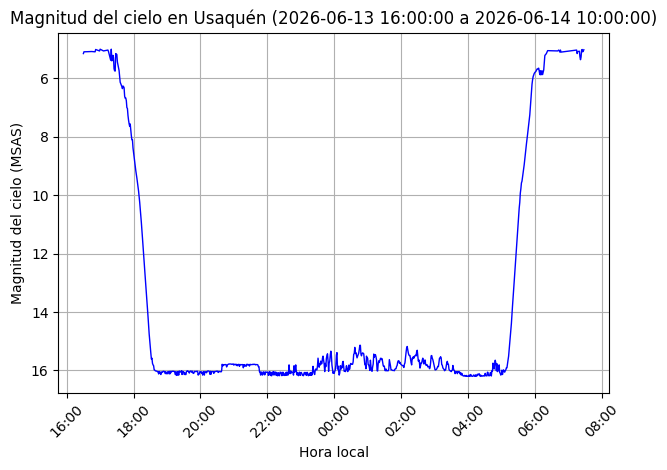

In [13]:
plt.plot(df_filtrado["local_datetime"], df_filtrado["msas"], linestyle='-', linewidth=1, 
         color='blue')    
plt.xlabel("Hora local")
plt.ylabel("Magnitud del cielo (MSAS)")
plt.title(f"Magnitud del cielo en Usaquén ({inicio} a {fin})")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.grid()
plt.tight_layout()
plt.savefig(f"magnitud_cielo_usaquen_{inicio}_a_{fin}.png")
plt.show()

In [14]:
inicio_mis_datos = pd.to_datetime("2026-06-13 16:00:00")


df_mis_datos = df[
    (df["local_datetime"] >= inicio_mis_datos)]

print(df_mis_datos)

             utc_datetime      local_datetime  temperature_c  voltage   msas  \
3694  2026-06-13 21:30:05 2026-06-13 16:30:05           20.6     5.12   5.15   
3695  2026-06-13 21:31:05 2026-06-13 16:31:05           20.3     5.12   5.09   
3696  2026-06-13 21:45:05 2026-06-13 16:45:05           20.3     5.12   5.08   
3697  2026-06-13 21:51:05 2026-06-13 16:51:05           20.3     5.12   5.09   
3698  2026-06-13 21:52:05 2026-06-13 16:52:05           19.3     5.12   5.01   
...                   ...                 ...            ...      ...    ...   
10233 2026-06-21 23:20:05 2026-06-21 18:20:05           15.1     5.10  12.75   
10234 2026-06-21 23:21:05 2026-06-21 18:21:05           15.4     5.10  13.02   
10235 2026-06-21 23:22:05 2026-06-21 18:22:05           15.4     5.10  13.27   
10236 2026-06-21 23:23:05 2026-06-21 18:23:05           15.1     5.12  13.45   
10237 2026-06-21 23:24:22 2026-06-21 18:24:22           15.4     4.90   9.10   

       record_type  
3694             1

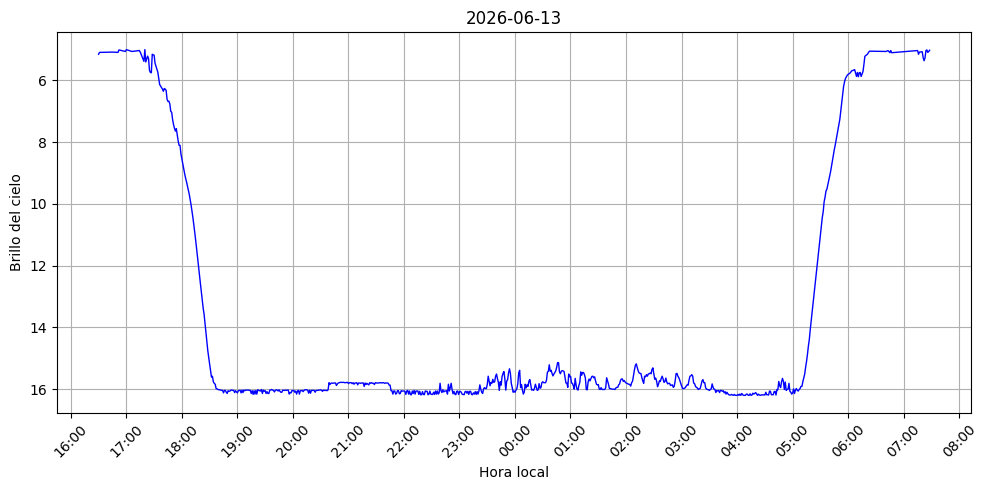

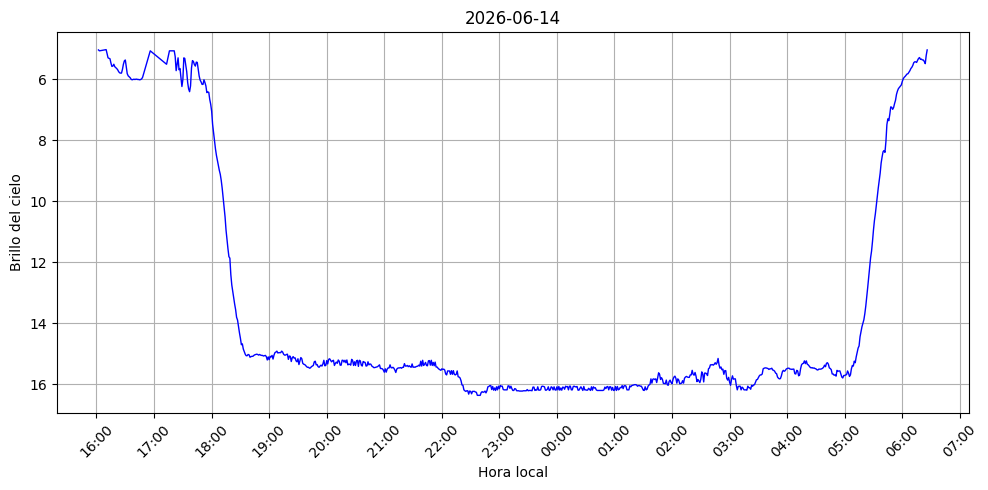

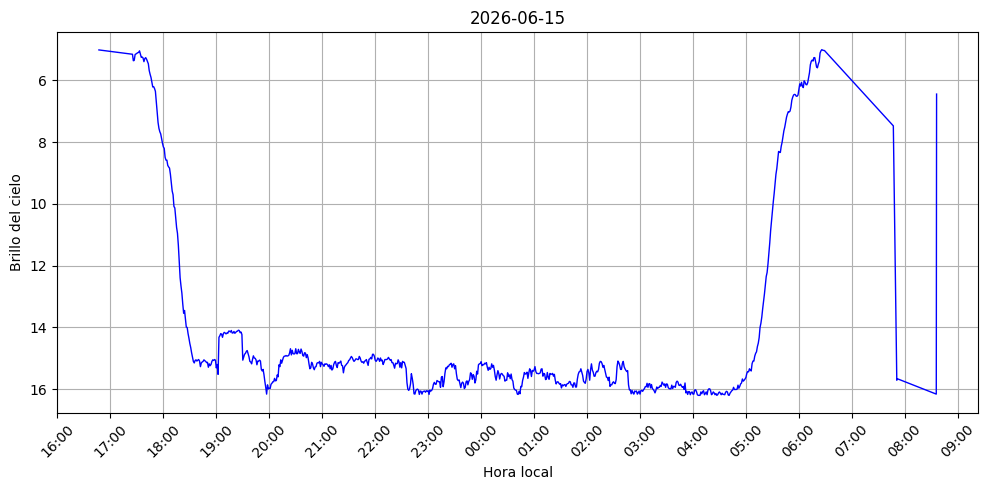

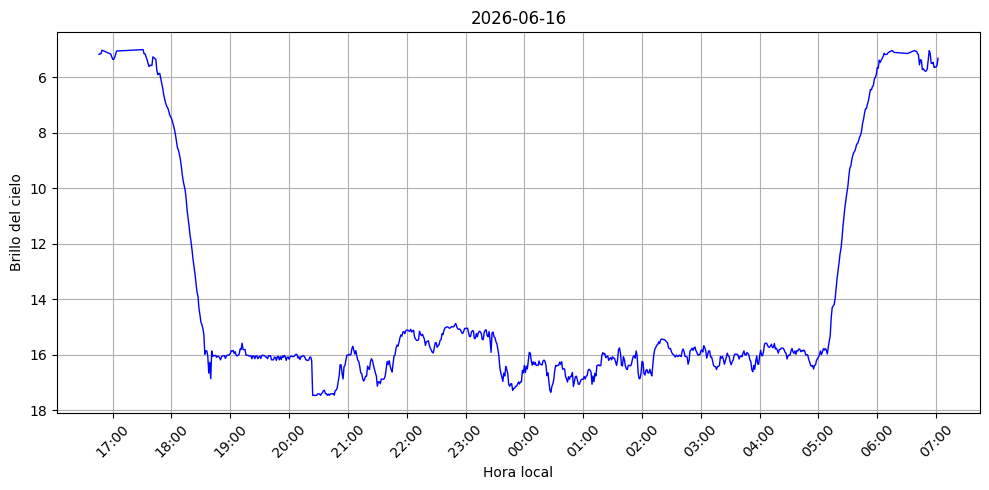

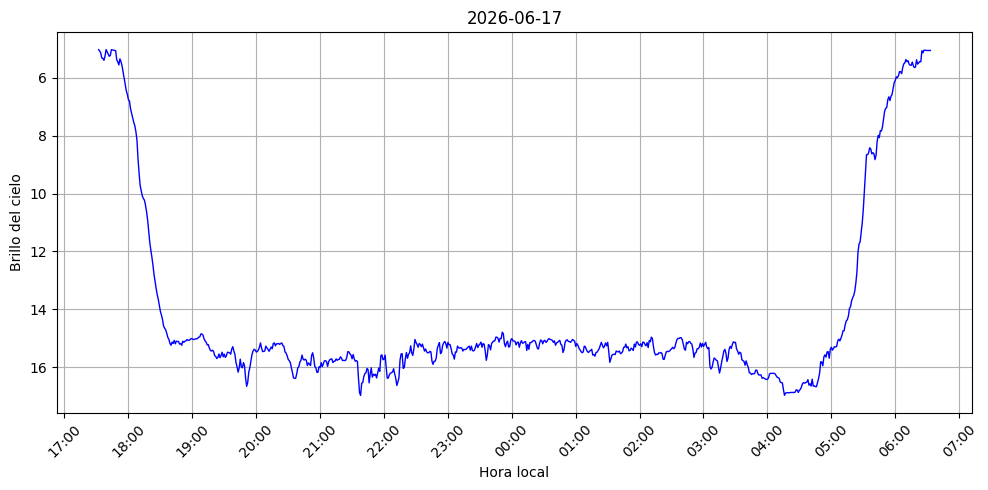

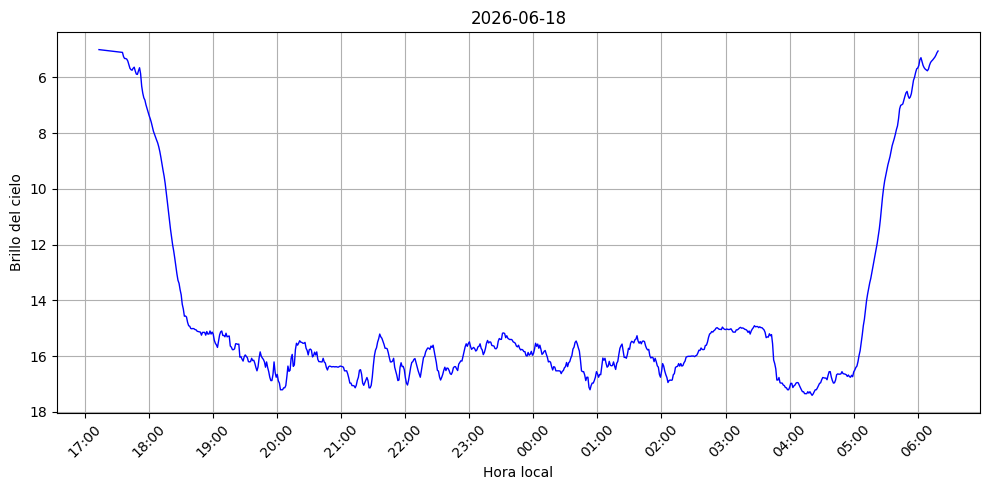

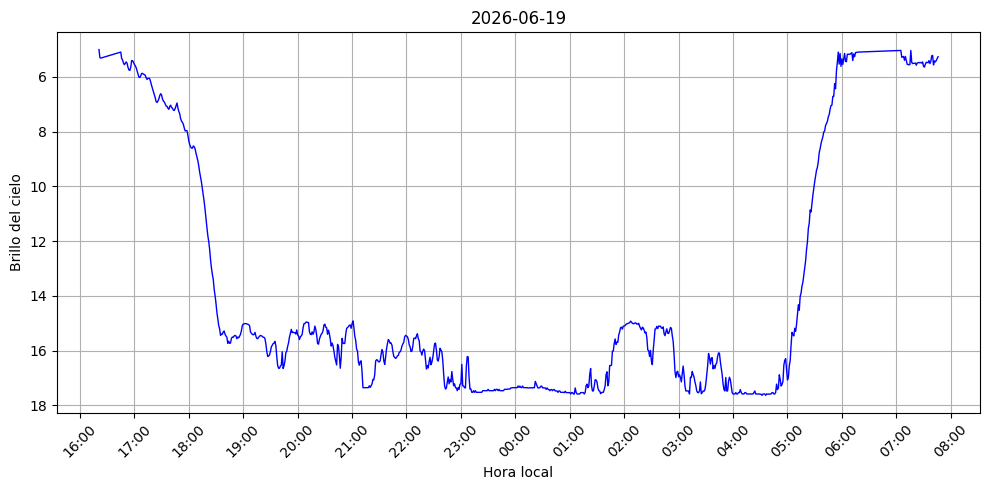

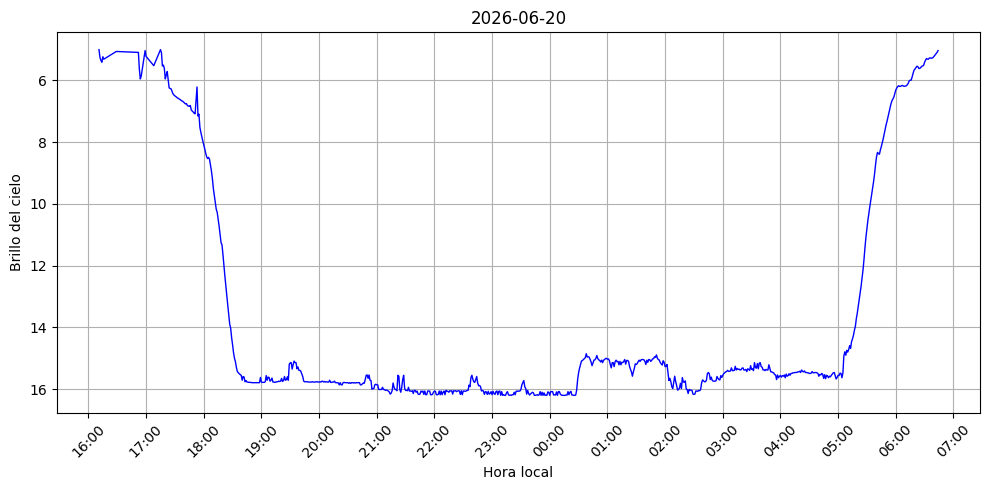

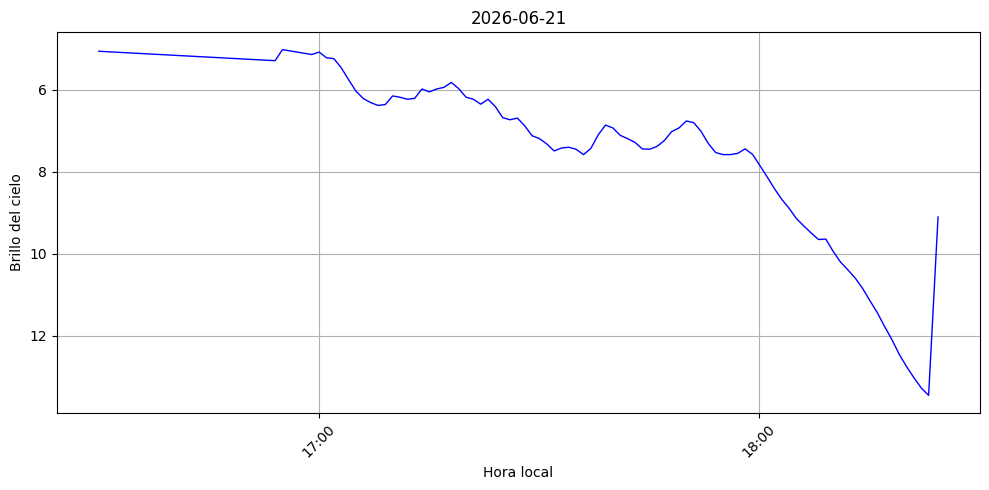

PDF guardado: graficas_sqm_usaquen/graficas_sqm_usaquen.pdf


In [ ]:
carpeta_salida = "graficas_sqm_usaquen"
os.makedirs(carpeta_salida, exist_ok=True)

ruta_pdf_unico = os.path.join(carpeta_salida, "graficas_sqm_usaquen_2.pdf")

fecha_inicial = df_mis_datos["local_datetime"].min().normalize()
fecha_final = df_mis_datos["local_datetime"].max().normalize()

with PdfPages(ruta_pdf_unico) as pdf:

    for dia in pd.date_range(fecha_inicial, fecha_final, freq="D"):

        inicio = dia + pd.Timedelta(hours=16)
        fin = dia + pd.Timedelta(days=1, hours=10)

        df_filtrado = df_mis_datos[
            (df_mis_datos["local_datetime"] >= inicio) &
            (df_mis_datos["local_datetime"] <= fin)
        ]

        if df_filtrado.empty:
            continue

        fig, ax = plt.subplots(figsize=(10, 5))

        ax.plot(
            df_filtrado["local_datetime"],
            df_filtrado["msas"],
            linestyle="-",
            linewidth=1,
            color="blue"
        )

        ax.set_xlabel("Hora local")
        ax.set_ylabel("Brillo del cielo")
        ax.set_title(dia.strftime("%Y-%m-%d"))

        # Mostrar cada hora en el eje X
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

        plt.xticks(rotation=45)

        ax.invert_yaxis()
        ax.grid()
        plt.tight_layout()

        pdf.savefig(fig)
        plt.show()
        plt.close(fig)

print(f"PDF guardado: {ruta_pdf_unico}")